## PISTE 2 - Classification des comportements

Apprentissage non supervisé => GMM

#### 0. Initialisation:

In [1]:
#install.packages("corrplot")

In [2]:
library("caret")
library("cluster")
library("corrplot")
library("corrr")
library("CVglasso")
library("e1071")
library("fda")
library("ggplot2")
library("glasso")
library("igraph")
library("mclust")
library("nnet")
library("pls")
library("psychTools")
library("qgraph")
library("randomForest")
library("readr")
library("splines")
library("tibble")
library("tidymodels")
library("VGAM")
library("xgboost")

Le chargement a nécessité le package : ggplot2

Le chargement a nécessité le package : lattice

corrplot 0.95 loaded


Attachement du package : ‘e1071’


L'objet suivant est masqué depuis ‘package:ggplot2’:

    element


Le chargement a nécessité le package : splines

Le chargement a nécessité le package : fds

Le chargement a nécessité le package : rainbow

Le chargement a nécessité le package : MASS

Le chargement a nécessité le package : pcaPP

Le chargement a nécessité le package : RCurl

Le chargement a nécessité le package : deSolve


Attachement du package : ‘fda’


L'objet suivant est masqué depuis ‘package:lattice’:

    melanoma


L'objet suivant est masqué depuis ‘package:graphics’:

    matplot


L'objet suivant est masqué depuis ‘package:datasets’:

    gait



Attachement du package : ‘igraph’


Les objets suivants sont masqués depuis ‘package:stats’:

    decompose, spectrum


L'objet suivant est masqué depuis ‘package:base’:

    union


Package 'mclust' version 6.1.2


#### 1. Importation données:

In [3]:
beh_df <- read.csv('../../piste_2/data/multispec_bsplines_IGT.csv', row.names = 'X')
beh_df

,bspline_1_1,bspline_2_1,bspline_3_1,bspline_4_1,bspline_5_1,bspline_6_1,bspline_7_1,bspline_8_1,bspline_9_1,bspline_1_2,⋯,bspline_9_2,bspline_1_3,bspline_2_3,bspline_3_3,bspline_4_3,bspline_5_3,bspline_6_3,bspline_7_3,bspline_8_3,bspline_9_3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-2Dichloroethane0,0.0428599502,0.3104169809,0.5140330488,0.6217378048,0.0343168263,-0.3121616308,-0.1617780782,-0.6181177421,-0.6961151714,0.3191718511,⋯,0.254651357,0.1742133519,-0.290967797,0.457663353,-0.636516656,-0.610191538,-1.012258286,-0.720259341,-1.049027966,-0.860928113
1-2Dichloroethane1,0.0064556398,0.3925176002,0.8299189711,0.2694801130,0.5466829256,0.2493151690,-0.6337381047,0.4692707261,-0.3382460723,-0.0157996724,⋯,0.046915940,-0.0338080388,0.057187990,-0.093385392,0.142761434,-0.803631031,-0.638739310,-0.680812425,-0.432069494,-0.611039982
1-2Dichloroethane2,0.3279381580,-0.2646451337,0.4845137377,0.0235180885,0.0432431615,0.1191663208,0.0882769398,0.0231242212,0.0227816304,0.3542241057,⋯,-0.342825078,0.1500494456,-0.239516349,0.327802521,-0.311698492,-0.767715644,-0.787530033,-0.452401110,-0.770545783,-0.356287780
1-chlorodecane0,-0.0012663269,0.0212297344,-0.0143353314,0.0355292603,0.0156677416,0.0116948309,0.0606068544,0.0709572486,0.0206552934,0.0071250680,⋯,0.022286039,0.0000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000
4-octylphenol0,0.1919322615,-0.2855992927,0.4688403629,-0.4613242667,2.3234831092,0.6141764850,1.7872151736,-0.4778250813,0.9492905666,-0.0546228864,⋯,1.796629235,0.0861667801,-0.133266101,0.158973553,-0.030929314,0.115632488,0.322951751,0.117061066,0.912526483,0.400061044
4-octylphenol1,0.1919322615,-0.2855992927,0.4688403629,-0.4613242667,2.3234831092,0.6141764850,1.7872151736,-0.4778250813,0.9492905666,0.0684985358,⋯,1.131256475,0.0464723011,-0.098046006,0.204156632,0.270479648,0.423434660,0.586502351,1.392661378,0.570198885,0.912969638
124-Trichlorobenzene0,0.0080013122,0.0048791414,0.0135043987,0.0134059151,0.0004118712,0.0421897391,-0.0186243209,0.0045459801,0.0011581828,0.0820340491,⋯,0.010943155,0.0023898678,-0.003857041,0.005482283,-0.005999139,0.012015410,-0.027034034,0.069573587,0.131426491,-0.007837363
124-Trichlorobenzene1,0.0150202732,0.0208173917,0.0415044430,0.0180178136,0.0556598030,-0.0632748582,0.0416242482,0.0182982485,0.0045270320,-0.1114213676,⋯,-0.002631536,0.1671736117,0.030992751,-0.018535870,0.019734837,0.002392184,-0.041270413,0.195565456,-0.090925733,0.209472727
A7360,-0.0083587626,0.0129428213,-0.0122405416,0.0383206750,0.0023603288,0.0014072831,-0.0522923263,-0.0168930498,0.0002765820,0.0489670559,⋯,0.008477128,-0.0015143726,0.002437177,-0.003432376,0.003649616,-0.005972552,0.004682305,0.027621433,-0.020727465,0.008075005


#### 2. Classification comportement via GMM
=> pas besoin de normaliser les données comme elles l'ont déjà été précédemment

UPDATE: scale them.

RQ: feature engineering à peut-être faire en fonction des résultats obtenus

In [4]:
X_scaled <- scale(beh_df)

##### 2.1: Réduction espace dimensionnel via graphical LASSO

In [5]:
## STEP 1: matrice de covariance
S <- cov(X_scaled)

In [6]:
glasso_res <- glasso(S, rho = 0.4) #rho fixé, à optimiser normalement
Theta <- glasso_res$wi   # matrice de précision estimée

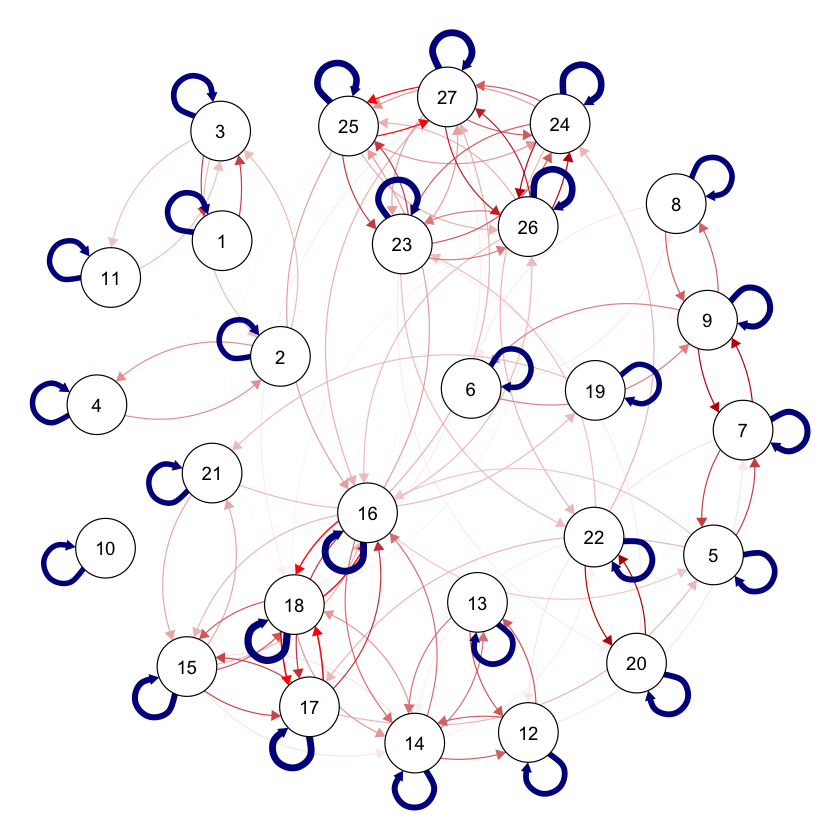

In [7]:
## STEP 2: visualiser le réseau
qgraph(Theta, theme = "colorblind", layout = "spring")#, details = TRUE)#, edge.color = c("red", "orange", "yellow", "cyan", "green"))

In [8]:
sum(abs(Theta) > 1e-5) - ncol(Theta)

[1] 102

In [9]:
p <- ncol(Theta)
edges <- (sum(abs(Theta) > 1e-5) - p) / 2
max_edges <- p*(p-1)/2

edges / max_edges ## if > 30%, still too dense, so fix lambda // if < 10%, too few so fix lambda

[1] 0.1452991

In [10]:
#### STEP 3: sélection B-splines pertinentes
X_glasso <- rowSums(abs(Theta)) - abs(diag(Theta))

In [11]:
X_keep <- (X_glasso > quantile(X_glasso, 0.2))

In [12]:
X_sel <- X_scaled[, X_keep]

In [13]:
head(X_sel)

,bspline_1_1,bspline_2_1,bspline_3_1,bspline_5_1,bspline_7_1,bspline_8_1,bspline_9_1,bspline_3_2,bspline_4_2,bspline_5_2,⋯,bspline_7_2,bspline_8_2,bspline_9_2,bspline_2_3,bspline_4_3,bspline_5_3,bspline_6_3,bspline_7_3,bspline_8_3,bspline_9_3
1-2Dichloroethane0,-0.07331096,0.8536645,0.9221171,-0.3372215,-0.44658060,-1.5297088,-1.83565760,0.5809863,0.6548380,0.8284720,⋯,-0.03270288,0.8394397,0.4673270175,-1.71381858,-2.123779485,-2.54111402,-3.27105229,-2.3112788,-3.6119856,-3.1186971
1-2Dichloroethane1,-0.30538330,1.1685804,1.8098815,0.7949080,-1.47944165,1.6329396,-0.88521316,0.5821796,0.4684090,-0.0679973,⋯,-0.33317730,0.1274903,-0.0003572569,0.29106118,0.470598090,-3.34222409,-2.08595130,-2.1913542,-1.5628354,-2.2534314
1-2Dichloroethane2,1.74402232,-1.3521190,0.8391561,-0.3174978,0.10065237,0.3353311,0.07362004,-0.1066605,0.6777026,0.3375589,⋯,-1.07585573,-0.7617451,-0.8777990915,-1.41753177,-1.042392788,-3.19348415,-2.55803450,-1.4969494,-2.6870420,-1.3713234
1-chlorodecane0,-0.35460974,-0.2555799,-0.5628071,-0.3784287,0.04009777,0.4744526,0.06797283,-0.6506472,-0.1764262,-0.3443622,⋯,-0.20868693,0.2763155,-0.0558076835,-0.03825991,-0.004684186,-0.01406755,-0.05935924,-0.1215817,-0.1277706,-0.1376371
4-octylphenol0,0.87700395,-1.4324935,0.7951077,4.7209444,3.81869421,-1.1216703,2.53428309,0.8831825,1.9226226,2.1867138,⋯,3.60497282,3.7487219,3.9388525539,-0.80568219,-0.107654253,0.46481269,0.96530206,0.2343016,2.9030718,1.2476191
4-octylphenol1,0.87700395,-1.4324935,0.7951077,4.7209444,3.81869421,-1.1216703,2.53428309,1.1648763,1.7082973,1.9934539,⋯,3.45567646,3.0536535,2.4408683335,-0.60286478,0.895798379,1.73954422,1.80149539,4.1123191,1.7660735,3.0236225


##### 2.2: Application modèles GMM:

In [14]:
## GMM automatique:
set.seed(42)
gmm_optim_K5 <- Mclust(unique(X_sel))
summary(gmm_optim_K5)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VVI (diagonal, varying volume and shape) model with 6 components: 

 log-likelihood  n  df       BIC       ICL
      -780.3348 69 257 -2648.835 -2648.915

Clustering table:
 1  2  3  4  5  6 
27 10 23  3  4  2 

In [15]:
png('../plots/classif_plot_K5.png', width = 3000, height = 2500, res = 300)
plot(gmm_optim_K5, what = 'classification', dimens = 1:3)
dev.off()

agg_record_9fba40ce3031 
                      2

In [16]:
## forcing GMM avec classes G (K=9) pour voir si similarités:
set.seed(42)
gmm_optim_K7 <- Mclust(X_sel, G = 7)
summary(gmm_optim_K7)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust EII (spherical, equal volume) model with 7 components: 

 log-likelihood  n  df       BIC       ICL
      -1514.711 69 154 -3681.475 -3682.511

Clustering table:
 1  2  3  4  5  6  7 
10  6  4 38  5  4  2 

In [17]:
png('../plots/classif_plot_K7.png', width = 3000, height = 2500, res = 300)
plot(gmm_optim_K7, what = 'uncertainty', dimens = 1:3)
dev.off()

agg_record_9fba4a1907f0 
                      2

In [18]:
gmm_optim_K5$uncertainty[gmm_optim_K5$uncertainty > 0.0001]

124-Trichlorobenzene0      alphaEndosulfan0       Benzo(a)pyrene1 
         0.0006337863          0.0005259410          0.0320333094 
   Trichloroethylene1 
         0.0060680992

In [19]:
png('../plots/bic_beh.png', width = 3000, height = 2400, res = 300)
bic_model <- mclustBIC(X_sel)
plot(bic_model)
dev.off()

agg_record_9fba521ab806 
                      2

In [20]:
png('../plots/icl_beh.png', width = 3000, height = 2400, res = 300)
icl_model <- mclustICL(X_sel)
plot(icl_model)
dev.off()

agg_record_9fba56e8b5f4 
                      2

In [21]:
summary(bic_model)

Best BIC values:
             VVI,6      VVI,5      VVI,4
BIC      -2648.835 -2814.3911 -2900.8381
BIC diff     0.000  -165.5562  -252.0032

In [22]:
summary(icl_model)

Best ICL values:
             VVI,6      VVI,5      VVI,4
ICL      -2648.915 -2814.4602 -2900.8616
ICL diff     0.000  -165.5454  -251.9468

In [23]:
entropy <- bic_model[, 6] - icl_model[, 6]
entropy

1           2           3           4           5           6 
0.000000000 0.003693182 0.103348461 0.023518701 0.069133076 0.079905304 
          7           8           9 
         NA          NA          NA

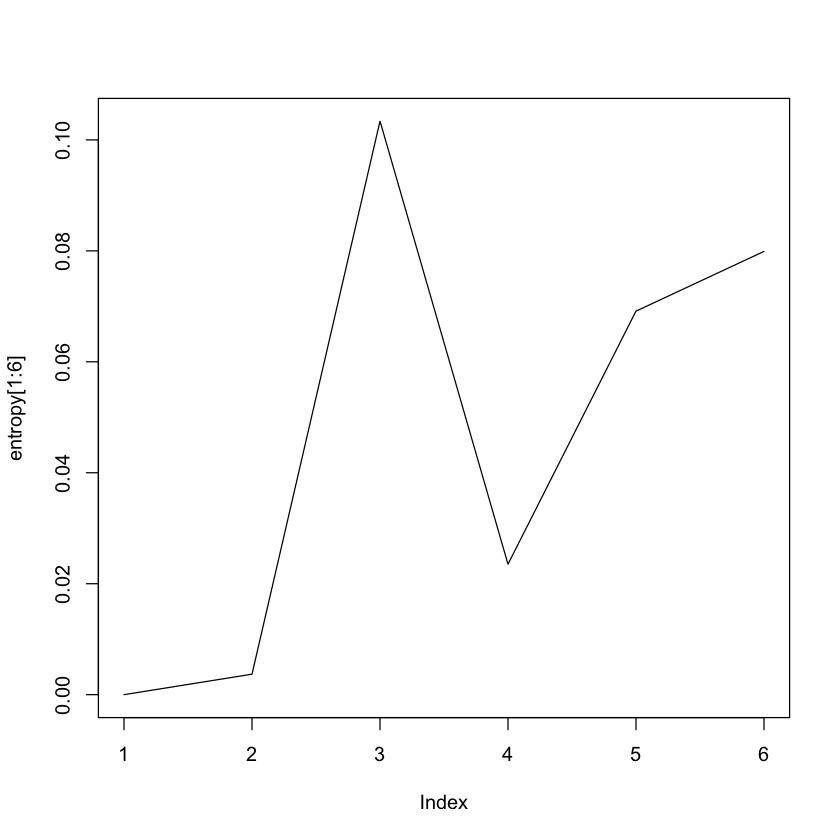

In [24]:
plot(entropy[1:6], type = "l")

##### 2.3: Matrice de co-association:
Quelles substances se retrouvent toujours ensemble, quel que soit le nombre de classes comportementales qu'on crée?

In [25]:
kmeans_optim <- kmeans(unique(X_sel), centers = 7)

In [26]:
## setup:
K_range <- 4:7
classes <- kmeans_optim$cluster
ordered_classes <- order(classes)
substances <- names(classes)

n <- length(substances)

count_common <- matrix(0, n, n, dimnames = list(substances, substances))

In [27]:
## create co-occ matrix for GMM classif:
for (k in K_range){
    GMM_k <- Mclust(unique(X_sel), G = k)
    classes_k <- GMM_k$classification
    count_common <- count_common + outer(classes_k, classes_k, FUN = "==")*1
}

## get proportion (+ informative):
M_consensus <- count_common / max(count_common)

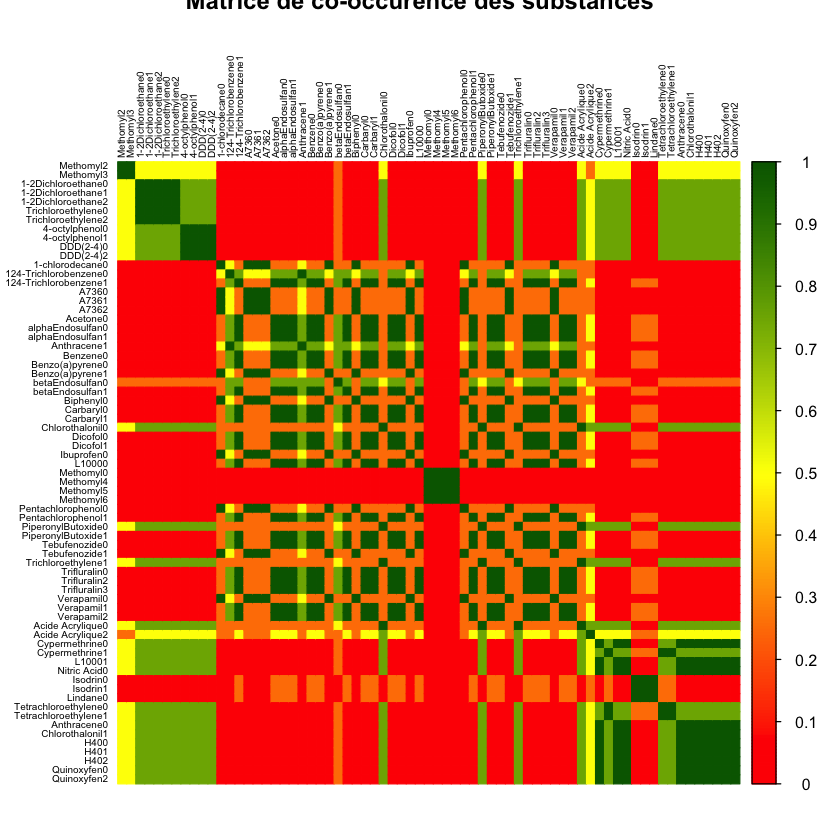

In [28]:
corrplot::corrplot(M_consensus[ordered_classes, ordered_classes], method = "color", type = "full", col = colorRampPalette(c("red", "yellow", "darkgreen"))(200), tl.col = "black", tl.cex = 0.5, is.corr = FALSE, title = "Matrice de co-occurence des substances")

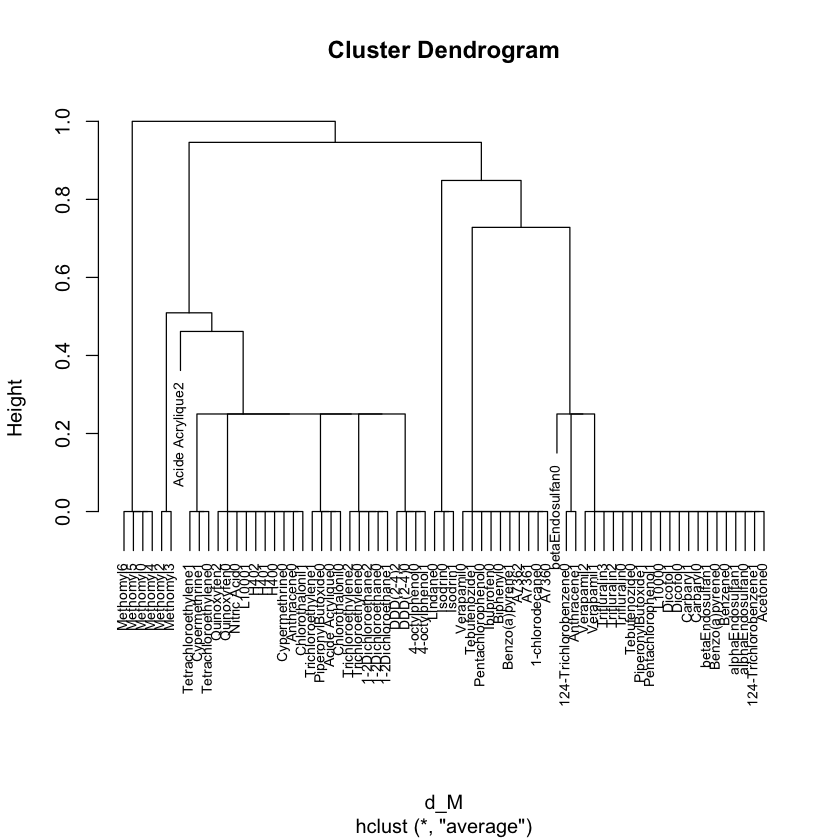

In [29]:
## hierarchical clustering to see subgroups:
d_M <- as.dist(1 - M_consensus)
h_clust <- hclust(d_M, method = "average")
final_labels <- cutree(h_clust, k = 7)

class_labels <- data.frame(substance = names(final_labels), y = final_labels)

plot(h_clust, cex = 0.7)

In [30]:
## re-ordered matrix:
index_ord <- h_clust$order

par(mar = c(2, 2, 4, 2))
png("../plots/coassoc_matrix_ordered_NO_AGG.png", width = 3400, height = 3300, res = 600)
corrplot::corrplot(M_consensus[index_ord, index_ord], method = "color", type = "full", col = colorRampPalette(c("red", "yellow", "darkgreen"))(200), tl.col = "black", tl.cex = 0.4, cl.cex = 0.6, cl.ratio  = 0.12, is.corr = FALSE, title = "Matrice de co-occurence des substances", mar = c(0, 0, 2, 0))
dev.off()

agg_record_9fba44f53755 
                      2

In [31]:
index_ord <- h_clust$order
par(mar = c(2, 2, 4, 2))
png("../plots/coassoc_matrix_ordered_NO_AGG.png", width = 3400, height = 3300, res = 600)
corrplot::corrplot(M_consensus[index_ord, index_ord], method = "color", type = "full",
                    col = colorRampPalette(c("red", "yellow", "darkgreen"))(200),
                    tl.col = "black", tl.cex = 0.4, cl.cex = 0.6, cl.ratio = 0.12,
                    is.corr = FALSE, title = "Matrice de co-occurence des substances",
                    mar = c(0, 0, 2, 0))
corrplot::corrRect.hclust(M_consensus[index_ord, index_ord], k = 7,
                           col = "blue4", lwd = 2, method = h_clust$method)
dev.off()

agg_record_9fba4f8cb652 
                      2

In [32]:
table(class_labels$y)


 1  2  3  4  5  6  7 
26 10 23  1  3  4  2 

In [33]:
table(gmm_optim_K7$classification)


 1  2  3  4  5  6  7 
10  6  4 38  5  4  2 

In [34]:
K_labels <- gmm_optim_K7$classification
table(K_labels)

K_labels
 1  2  3  4  5  6  7 
10  6  4 38  5  4  2 

In [35]:
posterior_list <- gmm_optim_K7$z
posterior_list[1:30, ]
posterior_list[31:60, ]
posterior_list[61:length(posterior_list[, 1]), ]

1-2Dichloroethane0,2.541089e-38,1.455619e-39,3.828275e-94,5.966922e-27,1.000000e+00,1.709840e-26,8.484526e-44
1-2Dichloroethane1,2.013268e-27,7.425401e-19,1.077300e-75,7.694832e-15,1.000000e+00,2.588669e-22,2.369240e-38
1-2Dichloroethane2,2.301564e-26,2.483471e-18,1.254123e-80,1.390953e-15,1.000000e+00,1.213385e-23,1.376050e-40
1-chlorodecane0,2.351784e-08,5.590054e-08,5.747223e-46,9.999999e-01,9.595813e-21,4.446659e-09,8.716188e-38
4-octylphenol0,6.765959e-30,6.911770e-75,1.000000e+00,7.103570e-49,5.784986e-83,1.154333e-68,2.393236e-78
4-octylphenol1,1.484918e-31,5.627952e-77,1.000000e+00,3.547544e-55,2.200775e-104,6.861955e-75,1.956985e-84
124-Trichlorobenzene0,2.756143e-07,1.152591e-07,1.864319e-46,9.999996e-01,1.322359e-21,2.958633e-08,1.162033e-36
124-Trichlorobenzene1,8.289455e-07,2.837175e-07,2.685039e-44,9.999989e-01,6.638902e-22,1.534356e-08,6.801853e-36
A7360,1.655129e-08,3.720327e-08,9.204336e-48,9.999999e-01,1.214015e-20,6.657632e-08,5.401911e-37
A7361,5.423190e-08,1.285450e-07,1.931206e-47,9.999998e-01,1.482011e-20,2.466322e-08,7.983033e-37
A7362,1.988348e-08,1.592427e-07,3.208060e-49,9.999998e-01,3.981998e-20,4.119548e-08,6.131070e-37


DDD(2-4)0,1.889777e-18,8.277473e-49,1.000000e+00,3.925141e-26,4.738248e-76,3.065684e-36,5.790928e-65
DDD(2-4)2,4.347383e-24,4.671168e-70,1.000000e+00,1.822305e-42,8.083597e-93,9.619351e-54,8.335912e-82
Dicofol0,1.181526e-06,2.447029e-07,1.562467e-43,9.999986e-01,2.266951e-15,2.259403e-09,1.662959e-24
Dicofol1,2.226077e-07,2.033651e-09,8.079114e-39,9.999998e-01,1.469223e-25,1.669839e-09,1.891331e-36
H400,1.000000e+00,8.529303e-27,1.380513e-21,8.734467e-09,3.583530e-29,1.142760e-11,1.328500e-35
H401,1.000000e+00,2.677707e-24,1.340014e-27,1.818702e-08,3.684865e-36,3.182585e-15,2.448079e-41
H402,1.000000e+00,4.651970e-23,1.903232e-28,1.753480e-09,7.673475e-46,1.917298e-17,1.018401e-45
Ibuprofen0,9.896836e-09,3.127739e-07,1.030479e-47,9.999997e-01,3.965848e-20,1.259744e-08,1.727657e-36
Isodrin0,1.330639e-19,9.997884e-01,2.992723e-77,2.115765e-04,3.778770e-24,7.109551e-11,1.243508e-39
Isodrin1,4.644385e-21,9.999968e-01,2.396372e-81,3.151358e-06,2.946846e-25,1.520907e-13,5.540841e-43
L10000,4.382261e-08,1.574854e-08,1.766077e-45,9.999996e-01,2.657787e-21,3.777916e-07,1.259948e-35


Trichloroethylene0,5.130780e-42,1.211560e-16,2.037399e-111,1.179972e-19,1.000000e+00,8.235106e-26,2.292762e-35
Trichloroethylene1,8.623940e-06,2.896586e-07,7.099156e-44,9.999911e-01,1.605628e-20,2.241816e-09,2.567389e-22
Trichloroethylene2,2.368858e-26,2.561884e-20,2.334906e-84,2.984652e-17,1.000000e+00,1.747160e-24,7.260622e-21
Trifluralin0,1.473047e-06,4.472747e-08,5.363862e-44,9.999972e-01,1.082034e-23,1.283312e-06,1.873071e-32
Trifluralin2,8.135755e-10,5.912746e-09,1.802473e-49,9.996814e-01,1.142188e-21,3.185978e-04,6.213985e-34
Trifluralin3,6.517075e-10,2.386270e-09,1.596927e-47,1.000000e+00,1.621336e-17,3.155848e-08,3.825548e-37
Verapamil0,1.762046e-06,3.693674e-08,4.890088e-43,9.999982e-01,1.956134e-21,1.502741e-08,4.184373e-37
Verapamil1,1.958073e-07,1.884685e-08,3.476921e-44,9.999998e-01,9.943595e-23,3.489649e-08,7.250322e-37
Verapamil2,3.594297e-07,3.259679e-10,1.942428e-42,9.999996e-01,2.678856e-21,1.061518e-08,4.523578e-37


In [36]:
df2latex(posterior_list, digits = 4)

% df2latex % posterior_list % 4 
\begin{table}[htpb]\caption{df2latex}
\begin{center}
\begin{scriptsize} 
\begin{tabular} {l r r r r r r r }
 \multicolumn{ 7 }{l}{ A table from the psych package in R } \cr 
 \hline Variable  &   {NA} &  {NA} &  {NA} &  {NA} &  {NA} &  {NA} &  {NA}\cr 
  \hline 
1-2Dichloroethane0   &  0.0000  &  0.0000  &  0.0000  &  0.0000  &  1.0000  &  0.0000  &  0.0000 \cr 
 1-2Dichloroethane1   &  0.0000  &  0.0000  &  0.0000  &  0.0000  &  1.0000  &  0.0000  &  0.0000 \cr 
 1-2Dichloroethane2   &  0.0000  &  0.0000  &  0.0000  &  0.0000  &  1.0000  &  0.0000  &  0.0000 \cr 
 1-chlorodecane0   &  0.0000  &  0.0000  &  0.0000  &  1.0000  &  0.0000  &  0.0000  &  0.0000 \cr 
 4-octylphenol0   &  0.0000  &  0.0000  &  1.0000  &  0.0000  &  0.0000  &  0.0000  &  0.0000 \cr 
 4-octylphenol1   &  0.0000  &  0.0000  &  1.0000  &  0.0000  &  0.0000  &  0.0000  &  0.0000 \cr 
 124-Trichlorobenzene0   &  0.0000  &  0.0000  &  0.0000  &  1.0000  &  0.0000  &  0.0000  &  0.00

In [37]:
posteriors <- as.data.frame(gmm_optim_K7$z)
colnames(posteriors) <- as.character(1:ncol(posteriors))
posteriors$substance <- substr(rownames(posteriors), 1, nchar(rownames(posteriors)) - 1)

In [38]:
agg_posteriors <- posteriors %>%
  group_by(substance) %>%
  summarise(across(where(is.numeric), median), .groups = "drop")

In [39]:
class_cols <- setdiff(names(agg_posteriors), "substance")

In [40]:
agg_posteriors <- agg_posteriors %>%
  rowwise() %>%
  mutate(
    final_class = class_cols[which.max(c_across(all_of(class_cols)))],
  ) %>%
  ungroup()

In [41]:
agg_posteriors

substance,1,2,3,4,5,6,7,final_class
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1-2Dichloroethane,2.013268e-27,7.425401e-19,1.254123e-80,1.390953e-15,1.000000e+00,1.213385e-23,1.376050e-40,5
1-chlorodecane,2.351784e-08,5.590054e-08,5.747223e-46,9.999999e-01,9.595813e-21,4.446659e-09,8.716188e-38,4
124-Trichlorobenzene,5.522799e-07,1.994883e-07,1.351841e-44,9.999992e-01,9.931244e-22,2.246495e-08,3.981943e-36,4
4-octylphenol,3.457225e-30,3.484025e-75,1.000000e+00,3.551787e-49,2.892493e-83,5.771668e-69,1.196619e-78,3
A736,1.988348e-08,1.285450e-07,9.204336e-48,9.999998e-01,1.482011e-20,4.119548e-08,6.131070e-37,4
Acetone,3.353140e-09,2.916222e-08,2.302017e-47,1.000000e+00,2.009276e-19,3.328294e-09,1.242160e-38,4
Acide Acrylique,8.300854e-02,6.019446e-06,7.089007e-36,9.169854e-01,6.214957e-20,3.192165e-08,2.554509e-37,4
Anthracene,4.863955e-01,2.900083e-08,9.416208e-33,5.136044e-01,8.401491e-22,2.869035e-09,1.315214e-36,4
Benzene,2.254799e-10,8.793867e-05,2.990815e-55,9.999120e-01,1.146648e-19,4.132355e-08,4.504858e-37,4


In [42]:
details_sub <- read.csv("../data/classes_df_forced_nomet_K7.csv", row.names = "X")
head(details_sub, 5)

,y,type
,<int>,<chr>
Carbaryl,2,insecticide
Cypermethrine,2,insecticide
DDD(2-4),2,insecticide
Dicofol,2,insecticide
Isodrin,3,insecticide


In [43]:
agg_posteriors_nw <- agg_posteriors$final_class
agg_posteriors_new <- as.data.frame(agg_posteriors_nw)
rownames(agg_posteriors_new) <- agg_posteriors$substance
agg_posteriors_new$substance <- agg_posteriors$substance
colnames(agg_posteriors_new) <- c("y", "substance")
agg_posteriors_new$substance_type <- details_sub$type[match(rownames(agg_posteriors_new), rownames(details_sub))]
agg_posteriors_new

,y,substance,substance_type
,<chr>,<chr>,<chr>
1-2Dichloroethane,5,1-2Dichloroethane,solvent
1-chlorodecane,4,1-chlorodecane,other
124-Trichlorobenzene,4,124-Trichlorobenzene,solvent
4-octylphenol,3,4-octylphenol,other
A736,4,A736,other
Acetone,4,Acetone,solvent
Acide Acrylique,4,Acide Acrylique,solvent
Anthracene,4,Anthracene,PAH
Benzene,4,Benzene,solvent


In [44]:
df2latex(agg_posteriors_new)

% df2latex % agg_posteriors_new 
\begin{table}[htpb]\caption{df2latex}
\begin{center}
\begin{scriptsize} 
\begin{tabular} {l r r r }
 \multicolumn{ 3 }{l}{ A table from the psych package in R } \cr 
 \hline Variable  &   {y} &  {sbstn} &  {sbst_}\cr 
  \hline 
1-2Dichloroethane   &  5  &  1-2Dichloroethane  &  solvent \cr 
 1-chlorodecane   &  4  &  1-chlorodecane  &  other \cr 
 124-Trichlorobenzene   &  4  &  124-Trichlorobenzene  &  solvent \cr 
 4-octylphenol   &  3  &  4-octylphenol  &  other \cr 
 A736   &  4  &  A736  &  other \cr 
 Acetone   &  4  &  Acetone  &  solvent \cr 
 Acide Acrylique   &  4  &  Acide Acrylique  &  solvent \cr 
 Anthracene   &  4  &  Anthracene  &  PAH \cr 
 Benzene   &  4  &  Benzene  &  solvent \cr 
 Benzo(a)pyrene   &  4  &  Benzo(a)pyrene  &  PAH \cr 
 Biphenyl   &  4  &  Biphenyl  &  other \cr 
 Carbaryl   &  4  &  Carbaryl  &  insecticide \cr 
 Chlorothalonil   &  4  &  Chlorothalonil  &  other pesticide \cr 
 Cypermethrine   &  2  &  Cypermethrine

In [45]:
table(agg_posteriors_new$y)


 1  2  3  4  5  6 
 3  4  2 21  2  1 

In [46]:
write_csv(agg_posteriors_new, '../data/classes_df_nomet_behaviour_K7_IGT.csv')